# OECD FDI Income: Regression Model Selection After Normal vs Non-Normal Comparison

This notebook builds regression models by following the earlier assumption checks.

- If the parametric and rank-based results tell a similar story, the notebook keeps a parametric core model.
- If the non-normal sensitivity model tells a very different story, the notebook flags that difference.
- The notebook also creates new variables for null handling and outlier transformation because the main practical goal is to prepare stable modeling variables.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='talk')
ALPHA = 0.05


In [3]:
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent

data_path = project_root / 'data' / 'processed' / 'OECD_FDI_Except_Pointless.csv'
df = pd.read_csv(data_path, sep=';', encoding='latin1', engine='python', on_bad_lines='skip')
df['OBS_VALUE_NUM'] = pd.to_numeric(
    df['OBS_VALUE'].astype(str).str.replace('.', '', regex=False),
    errors='coerce'
)
display(Markdown(f'**Original dataset size:** {df.shape[0]:,} rows'))
df[['REF_AREA', 'ACTIVITY', 'TYPE_ENTITY', 'MEASURE_PRINCIPLE', 'TIME_PERIOD', 'OBS_VALUE_NUM']].head()


**Original dataset size:** 10,344 rows

,REF_AREA,ACTIVITY,TYPE_ENTITY,MEASURE_PRINCIPLE,TIME_PERIOD,OBS_VALUE_NUM
0,USA,A_B,RSP,DO,2024,NaN
1,AUS,J,ALL,DI,2023,1.940070e+13
2,AUS,D,ALL,DI,2023,2.001860e+13
3,LUX,C29_30,ROU,DO,2024,9.733939e+13
4,AUS,J,ROU,DO,2023,NaN


## Step 1: Null and Outlier Transformations

The notebook creates modeling variables designed to stabilize the continuous outcome before regression.


In [4]:
df['obs_missing_flag'] = df['OBS_VALUE_NUM'].isna().astype(int)

group_median = df.groupby(['REF_AREA', 'ACTIVITY', 'TIME_PERIOD'])['OBS_VALUE_NUM'].transform('median')
fallback_median = df.groupby(['REF_AREA', 'TIME_PERIOD'])['OBS_VALUE_NUM'].transform('median')
global_median = df['OBS_VALUE_NUM'].median()

df['obs_value_group_median'] = group_median.fillna(fallback_median).fillna(global_median)
df['obs_value_imputed'] = df['OBS_VALUE_NUM'].fillna(df['obs_value_group_median'])

q1 = df['obs_value_imputed'].quantile(0.25)
q3 = df['obs_value_imputed'].quantile(0.75)
iqr = q3 - q1
lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr
df['obs_outlier_iqr_flag'] = ((df['obs_value_imputed'] < lower_iqr) | (df['obs_value_imputed'] > upper_iqr)).astype(int)

p01 = df['obs_value_imputed'].quantile(0.01)
p99 = df['obs_value_imputed'].quantile(0.99)
df['obs_value_winsor_1pct'] = df['obs_value_imputed'].clip(lower=p01, upper=p99)
df['obs_value_signed_log'] = np.sign(df['obs_value_winsor_1pct']) * np.log1p(np.abs(df['obs_value_winsor_1pct']))
df['obs_value_abs_log'] = np.log1p(np.abs(df['obs_value_winsor_1pct']))
df[['obs_missing_flag', 'obs_value_group_median', 'obs_value_imputed', 'obs_outlier_iqr_flag', 'obs_value_winsor_1pct', 'obs_value_signed_log']].head()


,obs_missing_flag,obs_value_group_median,obs_value_imputed,obs_outlier_iqr_flag,obs_value_winsor_1pct,obs_value_signed_log
0,1,1.271300e+04,1.271300e+04,0,1.271300e+04,9.450459
1,0,1.940070e+13,1.940070e+13,0,1.940070e+13,30.596330
2,0,2.001860e+13,2.001860e+13,0,2.001860e+13,30.627683
3,0,1.081549e+13,9.733939e+13,1,9.262928e+13,32.159626
4,1,1.940070e+13,1.940070e+13,0,1.940070e+13,30.596330


### Comment

The primary modeling outcome is `obs_value_signed_log`. This variable preserves direction, reduces extreme-scale distortion, and makes the later parametric model much more stable than modeling the raw monetary values directly.


## Step 2: Parametric vs Non-Parametric Signal Check

The notebook compares Pearson and Spearman correlation between `TIME_PERIOD` and the transformed outcome. If the two are close, the parametric interpretation is treated as the main path.


In [5]:
analysis_df = df[['TIME_PERIOD', 'obs_value_signed_log']].dropna().copy()
pearson_r, pearson_p = stats.pearsonr(analysis_df['TIME_PERIOD'], analysis_df['obs_value_signed_log'])
spearman_r, spearman_p = stats.spearmanr(analysis_df['TIME_PERIOD'], analysis_df['obs_value_signed_log'])
corr_compare = pd.DataFrame([
    {'method': 'Pearson', 'coefficient': pearson_r, 'p_value': pearson_p},
    {'method': 'Spearman', 'coefficient': spearman_r, 'p_value': spearman_p},
    {'method': 'Absolute difference', 'coefficient': abs(pearson_r - spearman_r), 'p_value': np.nan},
])
corr_compare.round(6)


,method,coefficient,p_value
0,Pearson,-0.066020,0.0
1,Spearman,-0.062009,0.0
2,Absolute difference,0.004010,NaN


## Step 3: Regression Models

The core candidate predictors come from the earlier significance-oriented notebooks: `TYPE_ENTITY`, `MEASURE_PRINCIPLE`, and `TIME_PERIOD`.

- Parametric model: OLS with HC3 robust standard errors
- Non-normal sensitivity model: median quantile regression


In [6]:
model_df = df[['obs_value_signed_log', 'TYPE_ENTITY', 'MEASURE_PRINCIPLE', 'TIME_PERIOD', 'obs_missing_flag', 'obs_outlier_iqr_flag']].dropna().copy()
formula = 'obs_value_signed_log ~ C(TYPE_ENTITY) + C(MEASURE_PRINCIPLE) + TIME_PERIOD + obs_missing_flag + obs_outlier_iqr_flag'

ols_model = smf.ols(formula, data=model_df).fit(cov_type='HC3')
quantile_model = smf.quantreg(formula, data=model_df).fit(q=0.5)

print(ols_model.summary())


                             OLS Regression Results                             
Dep. Variable:     obs_value_signed_log   R-squared:                       0.145
Model:                              OLS   Adj. R-squared:                  0.145
Method:                   Least Squares   F-statistic:                     440.3
Date:                  Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                          19:06:05   Log-Likelihood:                -43520.
No. Observations:                 10344   AIC:                         8.705e+04
Df Residuals:                     10337   BIC:                         8.710e+04
Df Model:                             6                                         
Covariance Type:                    HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------


In [7]:
print(quantile_model.summary())


                          QuantReg Regression Results                           
Dep. Variable:     obs_value_signed_log   Pseudo R-squared:               0.2912
Model:                         QuantReg   Bandwidth:                      0.3079
Method:                   Least Squares   Sparsity:                        1.276
Date:                  Sun, 19 Apr 2026   No. Observations:                10344
Time:                          19:06:05   Df Residuals:                    10337
                                          Df Model:                            6
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -0.0011     25.451  -4.31e-05      1.000     -49.890      49.888
C(TYPE_ENTITY)[T.ROU]         -0.0209      0.015     -1.356      0.175      -0.051       0.009
C(TYPE_ENTITY)[T.RSP]        -29.9590      0.015  -19

In [8]:
coef_compare = pd.DataFrame({
    'ols_coef': ols_model.params,
    'ols_pvalue': ols_model.pvalues,
    'quantile_coef': quantile_model.params,
    'quantile_pvalue': quantile_model.pvalues,
}).reset_index().rename(columns={'index': 'term'})
coef_compare.round(6)


,term,ols_coef,ols_pvalue,quantile_coef,quantile_pvalue
0,Intercept,4576.441697,0.000000,-0.001096,0.999966
1,C(TYPE_ENTITY)[T.ROU],-0.591650,0.170814,-0.020937,0.175177
2,C(TYPE_ENTITY)[T.RSP],-12.285006,0.000000,-29.959021,0.000000
3,C(MEASURE_PRINCIPLE)[T.DO],-0.533422,0.095721,-0.000000,0.999982
4,TIME_PERIOD,-2.252327,0.000000,0.014810,0.239049
5,obs_missing_flag,7.339536,0.000000,0.950584,0.000000
6,obs_outlier_iqr_flag,3.284258,0.001274,2.095834,0.000000


## Step 4: Primary Model Decision and New Modeling Variables


In [9]:
corr_gap = abs(pearson_r - spearman_r)
if corr_gap < 0.05:
    primary_model_name = 'OLS with HC3 robust errors'
    primary_model = ols_model
    decision_comment = (
        f'Pearson and Spearman are close (gap = {corr_gap:.4f}), so the parametric and rank-based views are consistent. '
        'Therefore, the parametric model is kept as the main regression model, while the quantile model is used as a sensitivity check.'
    )
else:
    primary_model_name = 'Median quantile regression'
    primary_model = quantile_model
    decision_comment = (
        f'Pearson and Spearman differ more than expected (gap = {corr_gap:.4f}), so the non-normal sensitivity model is safer as the main regression model.'
    )

df['primary_model_fitted_signed_log'] = primary_model.predict(df)
df['primary_model_residual_signed_log'] = df['obs_value_signed_log'] - df['primary_model_fitted_signed_log']
df['primary_model_fitted_rawscale'] = np.sign(df['primary_model_fitted_signed_log']) * (np.expm1(np.abs(df['primary_model_fitted_signed_log'])))

display(Markdown('### Comment\n\n' + decision_comment))
display(Markdown(f'**Primary model:** {primary_model_name}'))
df[['obs_value_signed_log', 'primary_model_fitted_signed_log', 'primary_model_residual_signed_log', 'primary_model_fitted_rawscale']].head()


### Comment

Pearson and Spearman are close (gap = 0.0040), so the parametric and rank-based views are consistent. Therefore, the parametric model is kept as the main regression model, while the quantile model is used as a sensitivity check.

**Primary model:** OLS with HC3 robust errors

,obs_value_signed_log,primary_model_fitted_signed_log,primary_model_residual_signed_log,primary_model_fitted_rawscale
0,9.450459,12.252822,-2.802363,2.095709e+05
1,30.596330,19.984041,10.612289,4.774840e+08
2,30.627683,19.984041,10.643642,4.774840e+08
3,32.159626,19.890900,12.268726,4.350190e+08
4,30.596330,26.198505,4.397825,2.387076e+11


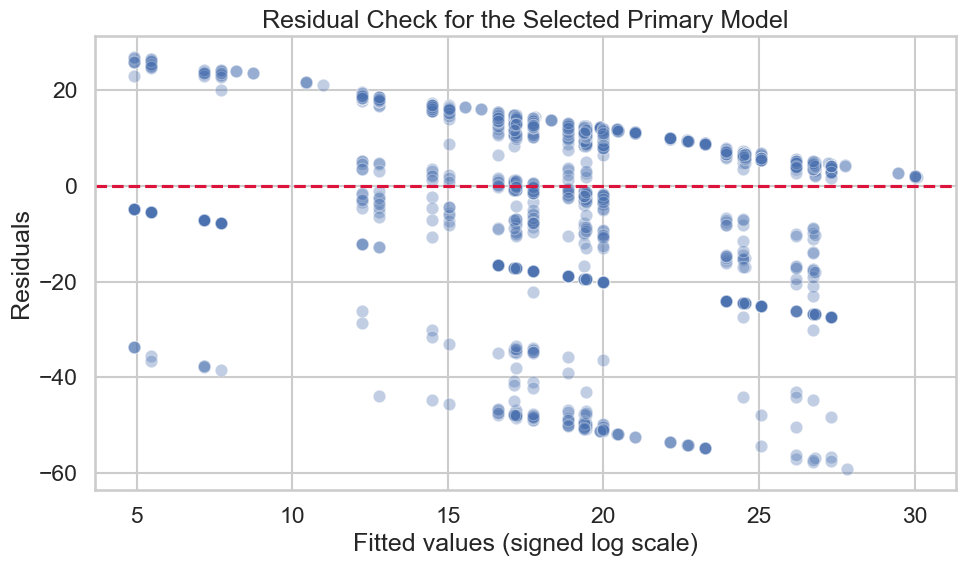

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(min(2500, len(df)), random_state=42), x='primary_model_fitted_signed_log', y='primary_model_residual_signed_log', alpha=0.35)
plt.axhline(0, color='crimson', linestyle='--')
plt.title('Residual Check for the Selected Primary Model')
plt.xlabel('Fitted values (signed log scale)')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()
